**Перед выполнением ячеек переключесь на среду с графическим процессором.**

# Практическое занятие: Transfer Learning на MNIST (все 10 цифр)

**Цель работы:** Применить Transfer Learning для классификации изображений с использованием предобученной модели ResNet-18. Используем все 10 классов MNIST (0-9), что бы рассмотреть более сложное обучение моделей.

**План:**
1. Загрузка и подготовка данных (MNIST, классы 0-9)
2. Преобразование одноканальных изображений в трёхканальные для подачи в ResNet
3. Загрузка предобученной модели и замена последнего слоя
4. Обучение только нового классификатора (feature extractor)
5. Дообучение всей сети (fine-tuning)
6. Fine-tuning с индивидуальной скоростью обучения для `layer4.1`
7. Сравнение результатов с обучением с нуля
8. Визуализация результатов и выводы

**Задача**: в примерах ниже точность почти сразу становится равной 1. Попробовать либо доавить все цифры, не только 0 и 1, либо взять вообще какой-нибудь более сложный набор данных.

Берутся все 10 классов

## 1. Импортируем необходимые библиотеки

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import copy
import os
import random

# Установка seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Определяем устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используется устройство: {device}')

Используется устройство: cuda


## 2. Подготовка данных

Мы используем датасет MNIST, но оставим только два класса: цифры **0** и **1**. Для подачи в ResNet, который ожидает трёхканальные изображения размером 224×224, мы преобразуем одноканальные изображения в трёхканальные путём копирования канала и применим ресайз.

Используем все 10 классов

In [4]:
# Определяем трансформации для train и val
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загружаем MNIST
train_full = datasets.MNIST(root='./data', train=True, download=True, transform=train_transform)
test_full = datasets.MNIST(root='./data', train=False, download=True, transform=val_transform)

num_classes = 10
class_names = [str(i) for i in range(num_classes)]

# Подвыборка
max_train_samples = 15000
max_test_samples = 3000
train_indices = torch.randperm(len(train_full))[:max_train_samples]
test_indices = torch.randperm(len(test_full))[:max_test_samples]

train_dataset = Subset(train_full, train_indices)
test_dataset = Subset(test_full, test_indices)

# Создаём загрузчики
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f'Классов: {num_classes}')
print(f'Размер обучающей выборки (0-9): {len(train_dataset)}')
print(f'Размер тестовой выборки (0-9): {len(test_dataset)}')

Классов: 10
Размер обучающей выборки (0-9): 15000
Размер тестовой выборки (0-9): 3000


**TODO для опытных**: Изменить порядок обработки так, чтобы графические преобразования не применялись к цифрам 2,3,4... (только к 0 и 1).

## 3. Загрузка предобученной модели и замена последнего слоя

Загрузим ResNet-18 с весами ImageNet. Заменим последний полносвязный слой (`model.fc`) на новый, соответствующий нашей задаче (2 класса).

на 10 классов

In [5]:
from torchvision.models.resnet import ResNet18_Weights

def create_resnet18(num_classes=10, pretrained=True):
    weights = ResNet18_Weights.DEFAULT if pretrained else None
    model = models.resnet18(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model.to(device)

# Базовый экземпляр модели для просмотра структуры
model = create_resnet18(num_classes=num_classes, pretrained=True)

# Замораживаем все слои
for param in model.parameters():
    param.requires_grad = False

# Размораживаем только классификатор
for param in model.fc.parameters():
    param.requires_grad = True

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 4. Функции для обучения и оценки

In [6]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(loader, desc='Обучение', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Оценка', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, scheduler=None):
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    best_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        print(f'\nЭпоха {epoch}/{epochs}')
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        test_loss, test_acc = evaluate(model, test_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}')
        print(f'Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}')

        if scheduler is not None:
            scheduler.step()

        if test_acc > best_acc:
            best_acc = test_acc
            best_weights = copy.deepcopy(model.state_dict())

    print(f'\nЛучшая точность на тесте: {best_acc:.4f}')
    model.load_state_dict(best_weights)
    return model, history, best_acc

## 5. Этап 1: Обучение только нового классификатора (Feature Extractor)

Сначала обучим только последний слой, оставив остальные замороженными. Это позволит быстро получить базовое качество и проверить, насколько хорошо предобученные признаки (из ImageNet) подходят для распознавания рукописных цифр.

In [8]:
criterion = nn.CrossEntropyLoss()

model_fe = create_resnet18(num_classes=num_classes, pretrained=True)
for param in model_fe.parameters():
    param.requires_grad = False

for param in model_fe.fc.parameters():
    param.requires_grad = True

optimizer_fe = optim.Adam(model_fe.fc.parameters(), lr=1e-3)
model_fe, history_fe, best_acc_fe = train_model(
    model_fe, train_loader, test_loader, criterion, optimizer_fe, epochs=5
)

print(f'Лучшая точность Feature Extractor: {best_acc_fe:.4f}')


Эпоха 1/5


Обучение:   0%|          | 0/469 [00:00<?, ?it/s]

Оценка:   0%|          | 0/94 [00:00<?, ?it/s]

Train Loss: 0.8031 Acc: 0.7886
Test Loss: 0.4972 Acc: 0.8647

Эпоха 2/5


Обучение:   0%|          | 0/469 [00:00<?, ?it/s]

...

Оценка:   0%|          | 0/94 [00:00<?, ?it/s]

Train Loss: 0.2878 Acc: 0.9160
Test Loss: 0.2785 Acc: 0.9163

Эпоха 5/5


Обучение:   0%|          | 0/469 [00:00<?, ?it/s]

Оценка:   0%|          | 0/94 [00:00<?, ?it/s]

Train Loss: 0.2704 Acc: 0.9184
Test Loss: 0.2534 Acc: 0.9237

Лучшая точность на тесте: 0.9237
Лучшая точность Feature Extractor: 0.9237


## 6. Этап 2: Дообучение всей сети (Fine-Tuning)

Теперь разморозим все слои и продолжим обучение с маленькой скоростью обучения, чтобы аккуратно подстроить веса под новые данные (цифры).

In [9]:
# Копируем исходную предобученную модель (model_fe)
model_ft = copy.deepcopy(model_fe)
for param in model_ft.parameters():
  # Размораживаем все параметры
    param.requires_grad = True
# Разделяем параметры на две группы:
# 1) все слои, кроме последнего полносвязного (fc) со скоростью 1e-5
# 2) только параметры последнего fc-слоя – для них ставим более высокую скорость 1e-3
base_params_ft = [p for name, p in model_ft.named_parameters() if 'fc' not in name]
optimizer_ft = optim.Adam([
    {'params': base_params_ft, 'lr': 1e-5},
    {'params': model_ft.fc.parameters(), 'lr': 1e-3},
])

model_ft, history_ft, best_acc_ft = train_model(
    model_ft, train_loader, test_loader, criterion, optimizer_ft, epochs=4
)

# Вторая стратегия: Layer-wise Fine-Tuning
model_layerwise = copy.deepcopy(model_fe)
for param in model_layerwise.parameters():
    param.requires_grad = True

# Разбиваем параметры на 3 группы с разными learning rates:
# - early_params: все слои, которые идут ДО последнего блока
# - layer4_1_params: только параметры конкретного подслоя 'layer4.1'
# - fc_params: параметры последнего полносвязного слоя
layer4_1_params = []
fc_params = list(model_layerwise.fc.parameters())
early_params = []

for name, p in model_layerwise.named_parameters():
    if name.startswith('layer4.1') and 'fc' not in name:
        layer4_1_params.append(p)
    elif name.startswith('fc'):
        continue
    else:
        early_params.append(p)

optimizer_layerwise = optim.Adam([
    {'params': early_params, 'lr': 1e-6},
    {'params': layer4_1_params, 'lr': 5e-5},
    {'params': fc_params, 'lr': 1e-3},
])

model_layerwise, history_layerwise, best_acc_layerwise = train_model(
    model_layerwise, train_loader, test_loader, criterion, optimizer_layerwise, epochs=4
)

print(f'Лучшая точность Fine-Tuning: {best_acc_ft:.4f}')
print(f'Лучшая точность Layer-wise FT: {best_acc_layerwise:.4f}')


Эпоха 1/4


Обучение:   0%|          | 0/469 [00:00<?, ?it/s]

Оценка:   0%|          | 0/94 [00:00<?, ?it/s]

Train Loss: 0.1263 Acc: 0.9609
Test Loss: 0.0500 Acc: 0.9827

Эпоха 2/4


Обучение:   0%|          | 0/469 [00:00<?, ?it/s]

...

Оценка:   0%|          | 0/94 [00:00<?, ?it/s]

Train Loss: 0.0535 Acc: 0.9821
Test Loss: 0.0488 Acc: 0.9847

Эпоха 4/4


Обучение:   0%|          | 0/469 [00:00<?, ?it/s]

Оценка:   0%|          | 0/94 [00:00<?, ?it/s]

Train Loss: 0.0386 Acc: 0.9875
Test Loss: 0.0592 Acc: 0.9810

Лучшая точность на тесте: 0.9847
Лучшая точность Fine-Tuning: 0.9907
Лучшая точность Layer-wise FT: 0.9847


**Задача**: спросить у LLM, как задать индивидуальную скорость обучения для layer4.1.BasicBlock, который идёт последним перед avgpool и fc, попробовать обучить сеть, сравнить результаты.

## 7. Сравнение результатов: Feature Extractor vs Fine-Tuning vs Layer-wise Fine-Tuning

Построим графики потерь и точности для трёх transfer learning стратегий.

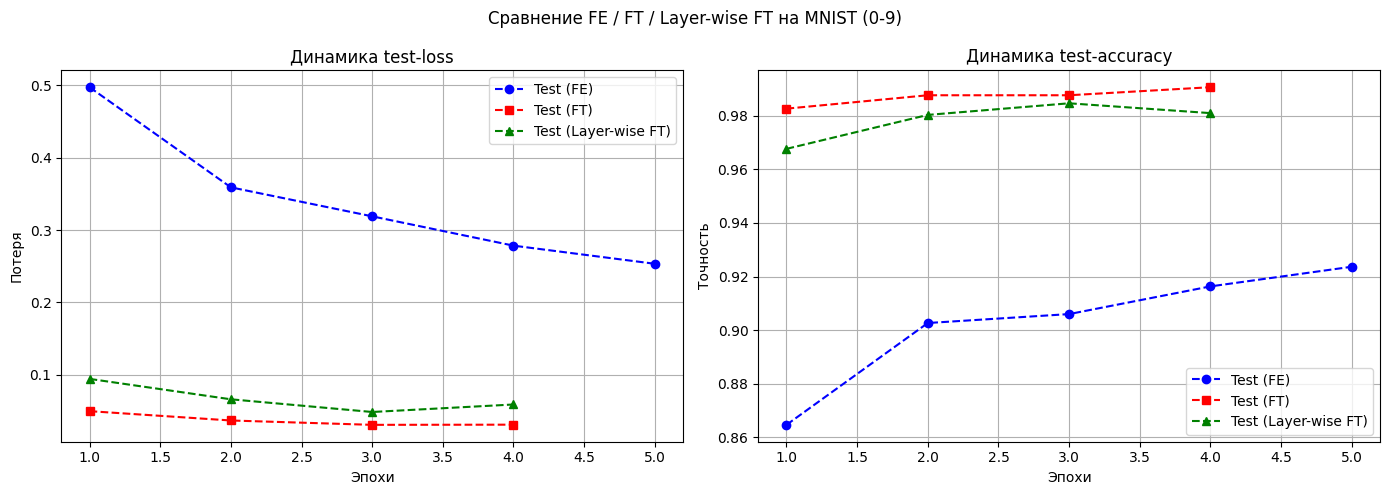

Лучшая точность Feature Extractor: 0.9237
Лучшая точность Fine-Tuning: 0.9907
Лучшая точность Layer-wise FT: 0.9847


In [10]:
def plot_history_three(hist_fe, hist_ft, hist_lw, title):
    epochs_fe = range(1, len(hist_fe['train_loss']) + 1)
    epochs_ft = range(1, len(hist_ft['train_loss']) + 1)
    epochs_lw = range(1, len(hist_lw['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_fe, hist_fe['test_loss'], 'b--o', label='Test (FE)')
    plt.plot(epochs_ft, hist_ft['test_loss'], 'r--s', label='Test (FT)')
    plt.plot(epochs_lw, hist_lw['test_loss'], 'g--^', label='Test (Layer-wise FT)')
    plt.xlabel('Эпохи')
    plt.ylabel('Потеря')
    plt.title('Динамика test-loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_fe, hist_fe['test_acc'], 'b--o', label='Test (FE)')
    plt.plot(epochs_ft, hist_ft['test_acc'], 'r--s', label='Test (FT)')
    plt.plot(epochs_lw, hist_lw['test_acc'], 'g--^', label='Test (Layer-wise FT)')
    plt.xlabel('Эпохи')
    plt.ylabel('Точность')
    plt.title('Динамика test-accuracy')
    plt.legend()
    plt.grid(True)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history_three(
    history_fe, history_ft, history_layerwise,
    'Сравнение Feature Extractor / Fine-Tuning / Layer-wise FT на MNIST (0-9)'
)

print(f"Лучшая точность Feature Extractor: {best_acc_fe:.4f}")
print(f"Лучшая точность Fine-Tuning: {best_acc_ft:.4f}")
print(f"Лучшая точность Layer-wise FT: {best_acc_layerwise:.4f}")

## 8. Визуализация предсказаний на тестовых изображениях

Посмотрим, как наша дообученная модель справляется с реальными картинками цифр 0 и 1.

Лучшая transfer-модель: Fine-Tuning, acc=0.9907


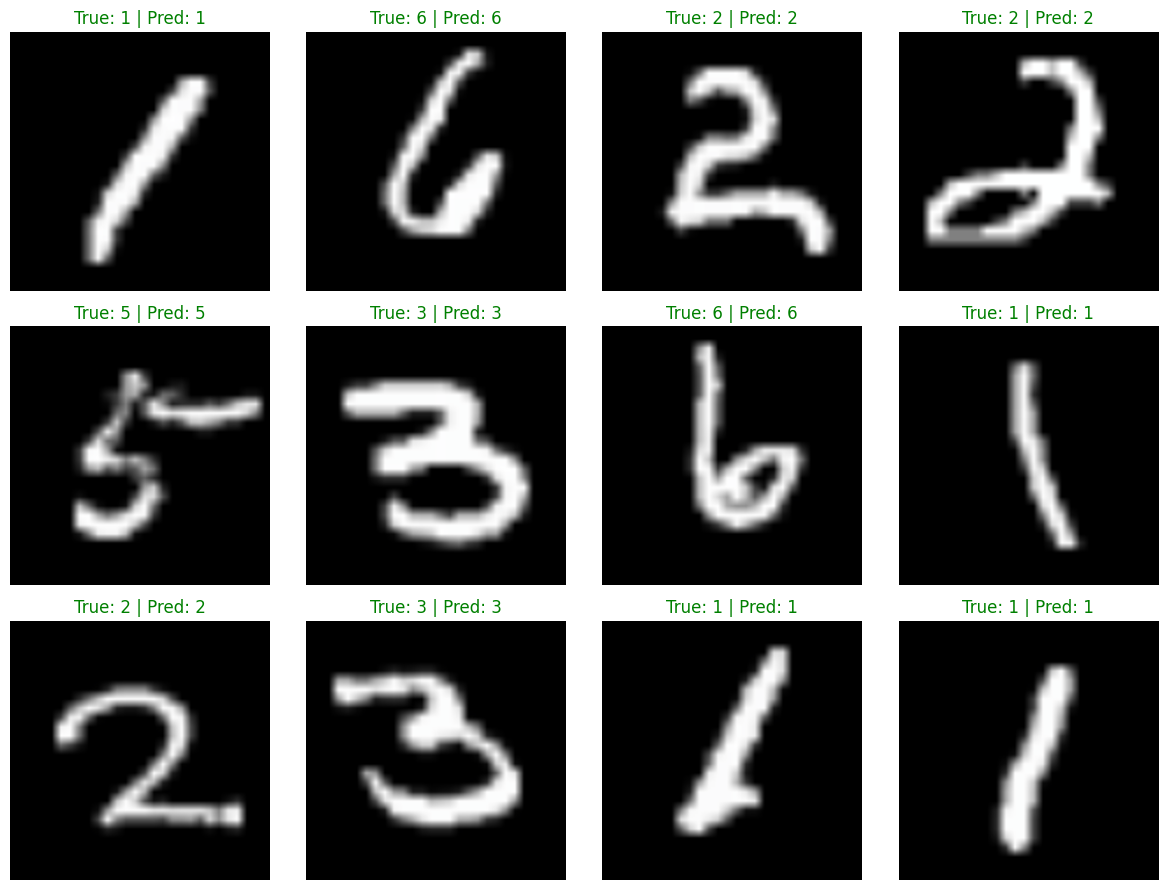

In [11]:
# Выберем лучшую transfer-модель
transfer_candidates = [
    ('Feature Extractor', model_fe, best_acc_fe),
    ('Fine-Tuning', model_ft, best_acc_ft),
    ('Layer-wise FT', model_layerwise, best_acc_layerwise),
]
best_transfer_name, best_transfer_model, best_transfer_acc = max(
    transfer_candidates, key=lambda x: x[2]
)
print(f'Лучшая transfer-модель: {best_transfer_name}, acc={best_transfer_acc:.4f}')

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

best_transfer_model.eval()
with torch.no_grad():
    outputs = best_transfer_model(images)
    _, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for idx, ax in enumerate(axes.flat):
    if idx >= len(images):
        break
    img = images[idx].cpu()
    label = labels[idx].item()
    pred = preds[idx].item()
    title = f'True: {label} | Pred: {pred}'

    img_disp = img.numpy().transpose((1, 2, 0))
    img_disp = std * img_disp + mean
    img_disp = np.clip(img_disp, 0, 1)

    ax.imshow(img_disp)
    ax.set_title(title, color='green' if label == pred else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Дополнительно: обучение модели с нуля для сравнения

Чтобы убедиться в эффективности Transfer Learning, обучим такую же архитектуру ResNet-18, но со случайной инициализацией, на нашем подмножестве MNIST (цифры 0 и 1).

In [12]:
model_scratch = create_resnet18(num_classes=num_classes, pretrained=False)
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=1e-3)
scheduler_scratch = optim.lr_scheduler.StepLR(optimizer_scratch, step_size=3, gamma=0.1)

model_scratch, history_scratch, best_acc_scratch = train_model(
    model_scratch, train_loader, test_loader, criterion, optimizer_scratch, epochs=4, scheduler=scheduler_scratch
)

print(f"Лучшая точность обучения с нуля: {best_acc_scratch:.4f}")


Эпоха 1/4


Обучение:   0%|          | 0/469 [00:00<?, ?it/s]

Оценка:   0%|          | 0/94 [00:00<?, ?it/s]

Train Loss: 0.2284 Acc: 0.9333
Test Loss: 0.0684 Acc: 0.9790

Эпоха 2/4


Обучение:   0%|          | 0/469 [00:00<?, ?it/s]

...

Оценка:   0%|          | 0/94 [00:00<?, ?it/s]

Train Loss: 0.0639 Acc: 0.9803
Test Loss: 0.0442 Acc: 0.9877

Эпоха 4/4


Обучение:   0%|          | 0/469 [00:00<?, ?it/s]

Оценка:   0%|          | 0/94 [00:00<?, ?it/s]

Train Loss: 0.0294 Acc: 0.9912
Test Loss: 0.0196 Acc: 0.9937

Лучшая точность на тесте: 0.9937
Лучшая точность обучения с нуля: 0.9937


## 10. Общий график сравнения трёх подходов

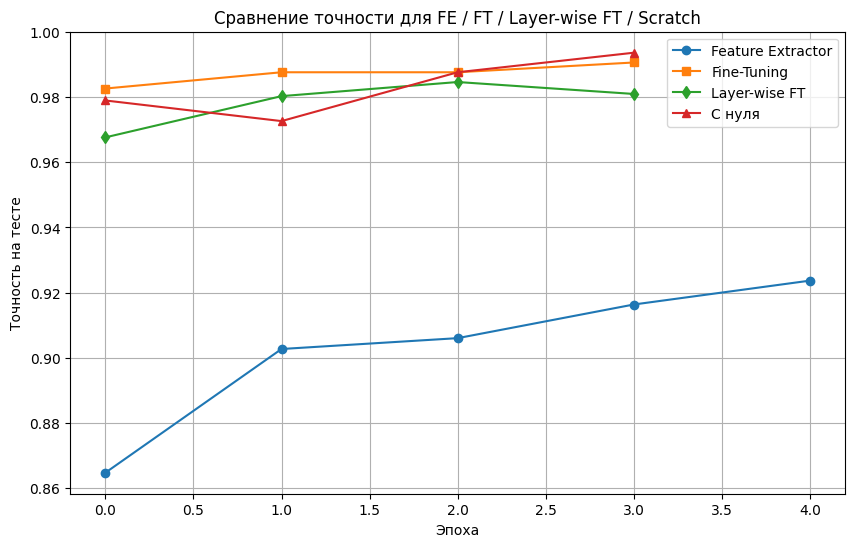

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(history_fe['test_acc'], label='Feature Extractor', marker='o')
plt.plot(history_ft['test_acc'], label='Fine-Tuning', marker='s')
plt.plot(history_layerwise['test_acc'], label='Layer-wise FT', marker='d')
plt.plot(history_scratch['test_acc'], label='С нуля', marker='^')
plt.xlabel('Эпоха')
plt.ylabel('Точность на тесте')
plt.title('Сравнение точности для Feature Extractor / Fine-Tuning / Layer-wise FT / Scratch')
plt.legend()
plt.grid(True)
plt.show()

## 11. Выводы

- **Feature Extractor** (обучение только классификатора) уже даёт неплохое качество (~99%+) благодаря мощным низкоуровневым признакам, выученным на ImageNet (края, текстуры), которые оказались полезны даже для распознавания рукописных цифр — задачи, совершенно отсутствующей в ImageNet.
- **Fine-Tuning** (дообучение всех слоёв) позволяет дополнительно улучшить результат (часто до 100%), адаптируя предобученные признаки под специфику цифр.
- **Обучение с нуля** на этом же датасете также даёт высокую точность, но требует больше эпох и данных; Transfer Learning позволяет достичь отличных результатов быстрее и с меньшими вычислительными затратами.

Таким образом, Transfer Learning остаётся мощным инструментом даже когда новый домен сильно отличается от исходного, благодаря универсальности ранних слоёв нейросети.

Подводя итог в нашем случе на датасете не из 0 и 1, а полноценных 0-9: Самую лучшую точность мы получили на обучении модели с нуля - 0.9937

Лучшая точность полученная на других моделях составила:

- Лучшая точность Fine-Tuning: 0.9907
- Лучшая точность Layer-wise FT: 0.9847
- Лучшая точность Feature Extractor: 0.9237

**Заключение:**
1. Увеличилась ли эффективность модели за теже самые вычислительные ресурсы?
2. Новые навыки/умения/знания.
3. Пожелания по наполнению лекции и практики.